### This notebook extract newly generated molecules after the DORAnet run: 

In [1]:
import os
import glob
import pandas as pd
from pathlib import Path
from collections import defaultdict
from rdkit import RDLogger
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw
from PIL import Image, ImageDraw, ImageFont
import numpy as np
import io
import json

RDLogger.DisableLog('rdApp.*')

In [2]:
from DORA_XGB import DORA_XGB
by_desc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_descending_MW')
by_asc_MW_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'by_ascending_MW')
add_concat_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_concat')
add_subtract_model = DORA_XGB.feasibility_classifier(cofactor_positioning = 'add_subtract')

/users/sghosh6/.conda/envs/doranet_env/lib/python3.10/site-packages/xgboost/compat.py:105: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
fileNamePrefix = "GuanosineOnly_gen3"

### Discover All Starter Directories

In [4]:
doranetOutputDir = "doranet_output"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

Output directory: doranet_output
Number of helpers to exclude: 33


In [5]:
# Automatically find all *_molecules.csv files in the current working directory
currentDir = os.getcwd()

allMoleculesCsvFiles = sorted(glob.glob(os.path.join(currentDir, "*_molecules.csv")))

print(f"Found {len(allMoleculesCsvFiles)} molecules CSV files in current directory")

# Parse discovered CSV files
discoveredCsvFiles = []

for csvPath in allMoleculesCsvFiles:
    fileName = os.path.basename(csvPath)
    dirName = fileName.replace('_molecules.csv', '')
    
    try:
        starterNum = int(dirName.replace('starter_', ''))
    except ValueError:
        starterNum = -1  # For non-standard naming

    discoveredCsvFiles.append({
        'dirName': dirName,
        'dirPath': currentDir,
        'csvPath': csvPath,
        'starterNum': starterNum
    })

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")

Found 1 molecules CSV files in current directory
Found 1 CSV files containing DORAnet generated molecules


### Extract the `DORAnet` starter molecule

In [6]:
user_starters = set()
starterReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        # Read only the SMILES and Is_Starter columns to save memory
        tempDF = pd.read_csv(
            fileInfo['csvPath'],
            usecols=['SMILES', 'Is_Starter']
        )
        starterSmiles = (
            tempDF[tempDF['Is_Starter'] == True]['SMILES']
            .dropna()
            .tolist()
        )
        user_starters.update(starterSmiles)

    except Exception as e:
        starterReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

if len(user_starters) == 0:
    raise ValueError("No starter molecules found across any CSV files!")

print(f"Number of unique starter molecules found: {len(user_starters)}")
for i, smi in enumerate(user_starters, 1):
    print(f"  Starter {i}: {smi}")

if starterReadErrors:
    print(f"\nFailed to read {len(starterReadErrors)} files:")
    for err in starterReadErrors:
        print(f"  {err['dirName']}: {err['error']}")

Number of unique starter molecules found: 1
  Starter 1: C1=NC2=C(N1[C@H]3[C@@H]([C@@H]([C@H](O3)CO)O)O)N=C(NC2=O)N


### Read `reaction_strings` from the `DORAnet` generated `json` file

In [7]:
jsonFile = f"{fileNamePrefix}_network_pretreated.json"

with open(jsonFile, "r", encoding="utf-8") as f:
    reactionList = json.load(f)

# Extract plain reaction strings: reactants >> products
plainReactionStrings = []
reactionRecords = []

uniqueReactantStrings = set()
uniqueProductStrings = set()
uniqueReactantMolecules = set()
uniqueProductMolecules = set()

for rxn in reactionList:
    parts = rxn.split(">")

    reactants = parts[0]
    ruleName = parts[1]
    metaBlock = parts[2]
    products = parts[3]

    plainRxn = f"{reactants} >> {products}"
    plainReactionStrings.append(plainRxn)

    uniqueReactantStrings.add(reactants)
    uniqueProductStrings.add(products)

    for mol in reactants.split("."):
        uniqueReactantMolecules.add(mol)

    for mol in products.split("."):
        uniqueProductMolecules.add(mol)

    reactionRecords.append({
        "reactants": reactants,
        "products": products,
        "reactionString": plainRxn,
        "ruleName": ruleName,
        "thermo": metaBlock.split("$")[0],
        "reactantStoich": metaBlock.split("$")[1],
        "productStoich": metaBlock.split("$")[2],
        "reactionType": metaBlock.split("$")[3],
        "numReactantMolecules": len(reactants.split(".")),
        "numProductMolecules": len(products.split(".")),
    })

reactionDF = pd.DataFrame(reactionRecords)

# Counts
numReactionSteps = len(reactionDF)
numUniqueReactantStrings = len(uniqueReactantStrings)
numUniqueProductStrings = len(uniqueProductStrings)
numUniqueReactantMolecules = len(uniqueReactantMolecules)
numUniqueProductMolecules = len(uniqueProductMolecules)

print(f"Total number of reaction: {numReactionSteps}")
print(f"Number of unique reactant strings: {numUniqueReactantStrings}")
print(f"Number of unique product strings: {numUniqueProductStrings}")
print(f"Number of unique individual reactant molecules: {numUniqueReactantMolecules}")
print(f"Number of unique individual product molecules: {numUniqueProductMolecules}")

reactionDF

Total number of reaction: 11965
Number of unique reactant strings: 3853
Number of unique product strings: 10584
Number of unique individual reactant molecules: 344
Number of unique individual product molecules: 6188


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules
0,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)n...,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c4nc(nc32)[nH]...,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)n...,rule0146_1,No_Thermo,"(1,)","(1, 1)",Enzymatic,1,2
1,CC(O)OC[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(=O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,CC(O)OC[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(=O...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3
2,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,CC(O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,rule0003_176,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
3,CC(O)(C#N)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](...,CC(O)Nc1nc2c(ncn2[C@@H]2O[C@H](C(O)C#N)[C@@H](...,CC(O)(C#N)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1
4,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,COC[C@H]1O[C@@H](n2c[n+](C)c3c(=O)[nH]c(N)nc32...,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,rule0121_1,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
...,...,...,...,...,...,...,...,...,...,...
11960,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3
11961,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](C)O[C@H]1n1cnc2c(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2
11962,CC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,CC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3
11963,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,CC(=O)O[C@@H]1[C@@H](C(=O)O)O[C@@H](n2cnc3c(=O...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2


### Use `DORA-XGB` to get feasibility score

In [8]:
reactionDF_DORAXGB = reactionDF.copy()

# Clean reaction string for model input
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

def getFeasibilityScoresAndLabels(rxnStr):
    return pd.Series({
        "feasibilityScore_rule1": by_desc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule1": by_desc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule2": by_asc_MW_model.predict_proba(rxnStr),
        "feasibilityLabel_rule2": by_asc_MW_model.predict_label(rxnStr),

        "feasibilityScore_rule3": add_concat_model.predict_proba(rxnStr),
        "feasibilityLabel_rule3": add_concat_model.predict_label(rxnStr),

        "feasibilityScore_rule4": add_subtract_model.predict_proba(rxnStr),
        "feasibilityLabel_rule4": add_subtract_model.predict_label(rxnStr),
    })

reactionDF_DORAXGB = reactionDF.copy()
reactionDF_DORAXGB["rxn_str"] = (
    reactionDF_DORAXGB["reactionString"]
    .astype(str)
    .str.replace(" ", "", regex=False)
)

reactionDF_DORAXGB[
    [
        "feasibilityScore_rule1",
        "feasibilityLabel_rule1",
        "feasibilityScore_rule2",
        "feasibilityLabel_rule2",
        "feasibilityScore_rule3",
        "feasibilityLabel_rule3",
        "feasibilityScore_rule4",
        "feasibilityLabel_rule4",
    ]
] = reactionDF_DORAXGB["rxn_str"].apply(getFeasibilityScoresAndLabels)

reactionDF_DORAXGB

,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)n...,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c4nc(nc32)[nH]...,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)n...,rule0146_1,No_Thermo,"(1,)","(1, 1)",Enzymatic,1,2,CC(=O)OC(=O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)n...,0.022462,0.0,0.078827,0.0,0.045461,0.0,0.216829,0.0
1,CC(O)OC[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(=O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,CC(O)OC[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(=O...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,CC(O)OC[C@H]1O[C@@H]2[C@H](O)[C@@H]1Oc1nc3c(=O...,0.000709,0.0,0.000740,0.0,0.080828,0.0,0.057759,0.0
2,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,CC(O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,rule0003_176,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,0.339769,0.0,0.800604,1.0,0.404675,0.0,0.888621,1.0
3,CC(O)(C#N)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](...,CC(O)Nc1nc2c(ncn2[C@@H]2O[C@H](C(O)C#N)[C@@H](...,CC(O)(C#N)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,CC(O)(C#N)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](...,0.019359,0.0,0.743944,1.0,0.693447,1.0,0.028730,0.0
4,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,COC[C@H]1O[C@@H](n2c[n+](C)c3c(=O)[nH]c(N)nc32...,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,rule0121_1,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,0.983307,1.0,0.828565,1.0,0.270089,0.0,0.913482,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11960,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,NC(=O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,0.002302,0.0,0.010867,0.0,0.022658,0.0,0.109712,0.0
11961,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,CC(=O)O[C@@H]1[C@H](O)[C@@H](C)O[C@H]1n1cnc2c(...,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,rule0062_19,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,CC(=O)SCCNC(=O)CCNC(=O)[C@H](O)C(C)(C)COP(=O)(...,0.379727,0.0,0.876337,1.0,0.949636,1.0,0.004875,0.0
11962,CC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,CC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,rule0004_13,No_Thermo,"(1, 1, 1)","(1, 1, 1)",Enzymatic,3,3,CC(O)[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,0.015118,0.0,0.019303,0.0,0.008236,0.0,0.051724,0.0
11963,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,CC(=O)O[C@@H]1[C@@H](C(=O)O)O[C@@H](n2cnc3c(=O...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,rule0126_2,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,0.001799,0.0,0.005309,0.0,0.001565,0.0,0.000007,0.0


### Keep only `high feasible` reactions

In [9]:
reactionDF_DORAXGB_highFeasibility = (
    reactionDF_DORAXGB[
        (reactionDF_DORAXGB["feasibilityLabel_rule1"] == 1)
        & (reactionDF_DORAXGB["feasibilityScore_rule1"].notna())
    ]
    .sort_values(by="feasibilityScore_rule1", ascending=False)
    .reset_index(drop=True)
)


uniqueReactantStrings_high = set(reactionDF_DORAXGB_highFeasibility["reactants"])
uniqueProductStrings_high = set(reactionDF_DORAXGB_highFeasibility["products"])

uniqueReactantMolecules_high = {
    mol
    for reactants in reactionDF_DORAXGB_highFeasibility["reactants"]
    for mol in str(reactants).split(".")
}

uniqueProductMolecules_high = {
    mol
    for products in reactionDF_DORAXGB_highFeasibility["products"]
    for mol in str(products).split(".")
}

print(f"Number of high-feasibility reactions: {len(reactionDF_DORAXGB_highFeasibility)}")
print(f"Number of unique reactant strings: {len(uniqueReactantStrings_high)}")
print(f"Number of unique product strings: {len(uniqueProductStrings_high)}")
print(f"Number of unique individual reactant molecules: {len(uniqueReactantMolecules_high)}")
print(f"Number of unique individual product molecules: {len(uniqueProductMolecules_high)}")
reactionDF_DORAXGB_highFeasibility

Number of high-feasibility reactions: 2545
Number of unique reactant strings: 1544
Number of unique product strings: 2162
Number of unique individual reactant molecules: 336
Number of unique individual product molecules: 1679


,reactants,products,reactionString,ruleName,thermo,reactantStoich,productStoich,reactionType,numReactantMolecules,numProductMolecules,rxn_str,feasibilityScore_rule1,feasibilityLabel_rule1,feasibilityScore_rule2,feasibilityLabel_rule2,feasibilityScore_rule3,feasibilityLabel_rule3,feasibilityScore_rule4,feasibilityLabel_rule4
0,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...,CC(=O)O.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(...,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...,rule0491_2,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,CC(O)O[C@@H]1[C@H](O)[C@@H](CO)O[C@H]1n1cnc2c(...,0.999962,1.0,0.993459,1.0,0.891995,1.0,0.838910,1.0
1,CC(=O)OP(=O)(O)O.O,CC(=O)O.O=P(O)(O)O,CC(=O)OP(=O)(O)O.O >> CC(=O)O.O=P(O)(O)O,rule0016_113,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,CC(=O)OP(=O)(O)O.O>>CC(=O)O.O=P(O)(O)O,0.999889,1.0,0.999953,1.0,0.999726,1.0,0.998597,1.0
2,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2cnc3c(=O)[n...,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2cnc3c(=O)[n...,rule0011_50,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,CO[C@H]1[C@@H](OS(=O)(=O)O)[C@H](n2cnc3c(=O)[n...,0.999888,1.0,0.915894,1.0,0.920821,1.0,0.025378,0.0
3,CC(O)OC1O[C@H]2[C@@H](O)[C@H](n3cnc4c(=O)[nH]c...,CC(O)O.NC(=O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O...,CC(O)OC1O[C@H]2[C@@H](O)[C@H](n3cnc4c(=O)[nH]c...,rule0491_2,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,CC(O)OC1O[C@H]2[C@@H](O)[C@H](n3cnc4c(=O)[nH]c...,0.999884,1.0,0.713173,1.0,0.917393,1.0,0.886655,1.0
4,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,rule0011_50,No_Thermo,"(1, 1)","(1, 1)",Enzymatic,2,2,C[S+](CC[C@H](N)C(=O)O)C[C@H]1O[C@@H](n2cnc3c(...,0.999851,1.0,0.981103,1.0,0.674020,1.0,0.283021,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2540,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](OC(=O)CO)[...,Nc1nc2c(ncn2[C@@H]2OC(CO)(CO)[C@@H](OC=O)[C@H]...,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](OC(=O)CO)[...,rule0028_50,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](OC(=O)CO)[...,0.585186,1.0,0.005395,0.0,0.063515,0.0,0.000475,0.0
2541,CC(=O)[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,CC(=O)[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,CC(=O)[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,rule0073_5,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,CC(=O)[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N)...,0.584512,1.0,0.466098,0.0,0.600252,1.0,0.670450,1.0
2542,C[C@@]1(CO)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,C[C@@]1(C=O)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C...,C[C@@]1(CO)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,rule0073_5,No_Thermo,"(1, 1, 1)","(1, 1, 1, 1)",Enzymatic,3,4,C[C@@]1(CO)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,0.584192,1.0,0.899782,1.0,0.919711,1.0,0.968296,1.0
2543,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,C[C@@]1(CO)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@...,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,rule0028_51,No_Thermo,"(1,)","(1,)",Enzymatic,1,1,CC(=O)O[C@H]1[C@@H](O)[C@H](n2cnc3c(=O)[nH]c(N...,0.583786,1.0,0.011122,0.0,0.012353,0.0,0.000058,0.0


In [10]:
def canonicalizeSMILES(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol is None:
            return None
        return Chem.MolToSmiles(mol, canonical=True)
    except Exception:
        return None


def extractSmilesSet(series):
    """
    Extract a flat set of SMILES from a column that may contain
    lists, tuples, semicolon-delimited strings, or dot-joined
    multi-molecule reaction sides.
    """
    smilesSet = set()
    for entry in series.dropna():
        if isinstance(entry, (list, tuple)):
            # Already split into individual SMILES
            for s in entry:
                s = s.strip()
                if s:
                    smilesSet.add(s)
        elif isinstance(entry, str):
            # First split by semicolon (if multiple entries per cell)
            for chunk in entry.split(";"):
                chunk = chunk.strip()
                # Then split by dot (multi-molecule reaction side e.g. "A.B")
                for mol in chunk.split("."):
                    mol = mol.strip()
                    if mol:
                        smilesSet.add(mol)
    return smilesSet


# --- Extract raw SMILES sets ---
rawReactantSet = extractSmilesSet(reactionDF_DORAXGB_highFeasibility["reactants"])
rawProductSet  = extractSmilesSet(reactionDF_DORAXGB_highFeasibility["products"])

# --- Canonicalize each set, dropping invalids ---
reactantSet = {c for s in rawReactantSet if (c := canonicalizeSMILES(s)) is not None}
productSet  = {c for s in rawProductSet  if (c := canonicalizeSMILES(s)) is not None}
starterSet  = {c for s in user_starters  if (c := canonicalizeSMILES(s)) is not None}

allMolecules = reactantSet | productSet | starterSet

# --- Print summary stats ---
print(f"Unique canonical reactant SMILES : {len(reactantSet)}")
print(f"Unique canonical product  SMILES : {len(productSet)}")
print(f"Unique canonical starter  SMILES : {len(starterSet)}")
print(f"Total unique canonical    SMILES : {len(allMolecules)}")
print(f"  (reactants only)               : {len(reactantSet - productSet - starterSet)}")
print(f"  (products only)                : {len(productSet - reactantSet - starterSet)}")
print(f"  (both reactant & product)      : {len(reactantSet & productSet)}")
print(f"Invalid/unparseable SMILES skipped:")
print(f"  reactants : {len(rawReactantSet) - len(reactantSet)}")
print(f"  products  : {len(rawProductSet)  - len(productSet)}")
print(f"  starters  : {len(user_starters)  - len(starterSet)}")


# --- Build rows (user starters first, then the rest) ---
rows = []

# User-defined starters go first
for smiles in starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    rows.append({
        "SMILES"          : smiles,
        "Is_reactant"     : isReactant,
        "Is_product"      : isProduct,
        "Is_Starter"      : True,
        "SourceDirectory" : fileNamePrefix,
    })

# Remaining molecules (excluding starters to avoid duplicates)
for smiles in allMolecules - starterSet:
    isReactant = smiles in reactantSet
    isProduct  = smiles in productSet
    isStarter  = isReactant and not isProduct
    rows.append({
        "SMILES"          : smiles,
        "Is_reactant"     : isReactant,
        "Is_product"      : isProduct,
        "Is_Starter"      : isStarter,
        "SourceDirectory" : fileNamePrefix,
    })

reactionDF_DORAXGB_highFeasibility_uniqueMolecules = (
    pd.DataFrame(rows)
    .drop_duplicates(subset="SMILES")
    .reset_index(drop=True)
)

print(f"\nFinal dataframe shape: {reactionDF_DORAXGB_highFeasibility_uniqueMolecules.shape}")
reactionDF_DORAXGB_highFeasibility_uniqueMolecules

Unique canonical reactant SMILES : 336
Unique canonical product  SMILES : 1679
Unique canonical starter  SMILES : 1
Total unique canonical    SMILES : 1846
  (reactants only)               : 167
  (products only)                : 1510
  (both reactant & product)      : 169
Invalid/unparseable SMILES skipped:
  reactants : 0
  products  : 0
  starters  : 0

Final dataframe shape: (1846, 5)


,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,True,True,True,GuanosineOnly_gen3
1,Cc1nc2c(=O)[nH]c(N)nc2n1[C@@H]1O[C@H](CO)[C@@H...,True,False,True,GuanosineOnly_gen3
2,CC(O)OC[C@H]1O[C@](C)(n2cnc3c(=O)[nH]c(N)nc32)...,False,True,False,GuanosineOnly_gen3
3,CC(C)(O)O[C@@H]1[C@H]2CO[C@@]1(O)[C@H](n1cnc3c...,False,True,False,GuanosineOnly_gen3
4,CO[C@H]1[C@@H](OC(C)=O)[C@H](n2cnc3c(=O)[nH]c(...,False,True,False,GuanosineOnly_gen3
...,...,...,...,...,...
1841,CC(O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@...,True,False,True,GuanosineOnly_gen3
1842,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,False,True,False,GuanosineOnly_gen3
1843,CC(C(=O)O)C(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]...,False,True,False,GuanosineOnly_gen3
1844,CC[C@@]1(COC=O)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32...,False,True,False,GuanosineOnly_gen3


### Remove HELPERS and Deduplicate

In [11]:
# Step 1: Remove helpers
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = reactionDF_DORAXGB_highFeasibility_uniqueMolecules[
    ~reactionDF_DORAXGB_highFeasibility_uniqueMolecules['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules) -
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)
)
helpersKeptPercent = (
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers) /
    len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules)
) * 100

print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Already deduplicated — just confirm no duplicates exist
duplicateCount = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].duplicated().sum()
print(f"\nStep 2 - Duplicate SMILES found: {duplicateCount}")

if duplicateCount > 0:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .drop_duplicates(subset='SMILES', keep='first')
        .reset_index(drop=True)
    )
    print(f"  Deduplicated to: {len(reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers)} molecules")
else:
    reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers = (
        reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers
        .reset_index(drop=True)
    )

# Step 4: Save
reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers.to_csv(
    f"{fileNamePrefix}_uniqueMolecules.csv", index=False, encoding="utf-8"
)
print(f"\nSaved to: {fileNamePrefix}_uniqueMolecules.csv")

reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers

Step 1 - Removed 18 helper molecules
Remaining molecules: 1828 (99.02%)

Step 2 - Duplicate SMILES found: 0

Saved to: GuanosineOnly_gen3_uniqueMolecules.csv


,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,True,True,True,GuanosineOnly_gen3
1,Cc1nc2c(=O)[nH]c(N)nc2n1[C@@H]1O[C@H](CO)[C@@H...,True,False,True,GuanosineOnly_gen3
2,CC(O)OC[C@H]1O[C@](C)(n2cnc3c(=O)[nH]c(N)nc32)...,False,True,False,GuanosineOnly_gen3
3,CC(C)(O)O[C@@H]1[C@H]2CO[C@@]1(O)[C@H](n1cnc3c...,False,True,False,GuanosineOnly_gen3
4,CO[C@H]1[C@@H](OC(C)=O)[C@H](n2cnc3c(=O)[nH]c(...,False,True,False,GuanosineOnly_gen3
...,...,...,...,...,...
1823,CC(O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@...,True,False,True,GuanosineOnly_gen3
1824,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,False,True,False,GuanosineOnly_gen3
1825,CC(C(=O)O)C(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]...,False,True,False,GuanosineOnly_gen3
1826,CC[C@@]1(COC=O)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32...,False,True,False,GuanosineOnly_gen3


In [12]:
def countAtoms(smiles: str) -> dict:
    """Count C, O, N, S atoms in a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return {'C_count': np.nan, 'O_count': np.nan, 'N_count': np.nan, 'S_count': np.nan}

    # Add explicit hydrogens if you also want H count
    atomCounts = {'C': 0, 'O': 0, 'N': 0, 'S': 0}
    for atom in mol.GetAtoms():
        symbol = atom.GetSymbol()
        if symbol in atomCounts:
            atomCounts[symbol] += 1

    return {
        'C_count': atomCounts['C'],
        'O_count': atomCounts['O'],
        'N_count': atomCounts['N'],
        'S_count': atomCounts['S']
    }


# Apply to each SMILES
atomCountsDF = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['SMILES'].apply(
    lambda s: pd.Series(countAtoms(s))
)

# Concatenate with original dataframe
uniqueMolecules_molCONS = pd.concat(
    [reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers, atomCountsDF],
    axis=1
)

uniqueMolecules_molCONS

,SMILES,Is_reactant,Is_product,Is_Starter,SourceDirectory,C_count,O_count,N_count,S_count
0,Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)...,True,True,True,GuanosineOnly_gen3,10,5,5,0
1,Cc1nc2c(=O)[nH]c(N)nc2n1[C@@H]1O[C@H](CO)[C@@H...,True,False,True,GuanosineOnly_gen3,12,6,5,0
2,CC(O)OC[C@H]1O[C@](C)(n2cnc3c(=O)[nH]c(N)nc32)...,False,True,False,GuanosineOnly_gen3,13,6,5,0
3,CC(C)(O)O[C@@H]1[C@H]2CO[C@@]1(O)[C@H](n1cnc3c...,False,True,False,GuanosineOnly_gen3,13,6,5,0
4,CO[C@H]1[C@@H](OC(C)=O)[C@H](n2cnc3c(=O)[nH]c(...,False,True,False,GuanosineOnly_gen3,13,5,5,0
...,...,...,...,...,...,...,...,...,...
1823,CC(O)Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@...,True,False,True,GuanosineOnly_gen3,12,6,5,0
1824,COC[C@H]1O[C@@H](n2cnc3c(=O)[nH]c(N)nc32)[C@H]...,False,True,False,GuanosineOnly_gen3,13,5,5,0
1825,CC(C(=O)O)C(=O)OC[C@H]1O[C@@H](n2cnc3c(=O)[nH]...,False,True,False,GuanosineOnly_gen3,14,8,5,0
1826,CC[C@@]1(COC=O)O[C@@H](n2cnc3c(=O)[nH]c(N)nc32...,False,True,False,GuanosineOnly_gen3,13,6,5,0


### Save as `.gif` image

Starter molecule: Nc1nc2c(ncn2[C@@H]2O[C@H](CO)[C@@H](O)[C@H]2O)c(=O)[nH]1
Starter molecules found: 164
Generated molecules found: 1664

Total generated (with duplicates): 1664
Unique generated molecules: 1664
Duplicates removed: 0

Total frames available: 555
Frames to generate: 100
Generated frame 50/100
Generated frame 100/100

Saved GIF: GuanosineOnly_gen3.gif
Total frames: 100, Frame size: 530 x 765


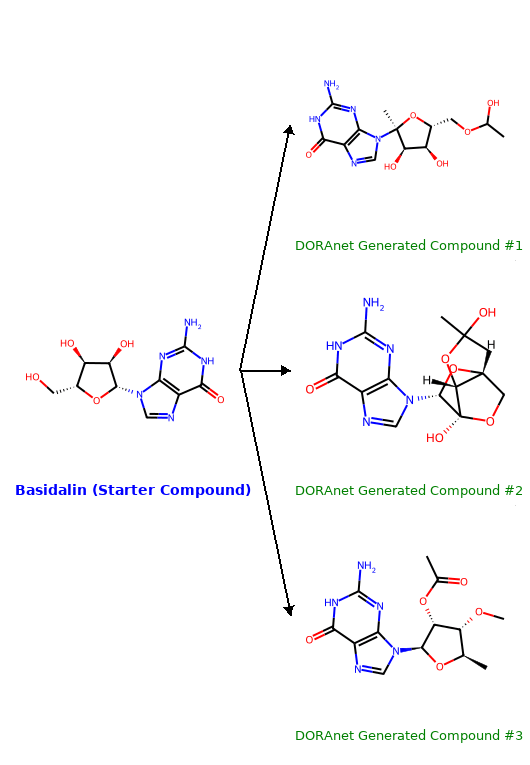

In [13]:
# Step 1: Read starter and generated molecules from uniqueMolecules
starterRows = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers[reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['Is_Starter'] == True]
generatedRows = reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers[reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers['Is_Starter'] == False]

if len(starterRows) == 0:
    raise ValueError("No starter molecule found (Is_Starter == True) in reactionDF_DORAXGB_highFeasibility_uniqueMolecules_noHelpers!")

STARTER_SMILES = starterRows['SMILES'].iloc[0]
print(f"Starter molecule: {STARTER_SMILES}")
print(f"Starter molecules found: {len(starterRows)}")
print(f"Generated molecules found: {len(generatedRows)}")

# Step 2: Get unique generated SMILES
uniqueGeneratedSmiles = generatedRows['SMILES'].unique().tolist()
duplicatesRemovedCount = len(generatedRows) - len(uniqueGeneratedSmiles)
print(f"\nTotal generated (with duplicates): {len(generatedRows)}")
print(f"Unique generated molecules: {len(uniqueGeneratedSmiles)}")
print(f"Duplicates removed: {duplicatesRemovedCount}")

# Step 3: Helper functions
import math

def smiles_to_image(smiles, img_size=(250, 250)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img = Image.new('RGB', img_size, 'white')
        ImageDraw.Draw(img).text((10, img_size[1] // 2), "Invalid SMILES", fill='red')
        return img
    return Draw.MolToImage(mol, size=img_size)

def draw_arrow(draw, x1, y1, x2, y2, width=2):
    draw.line([(x1, y1), (x2, y2)], fill='black', width=width)
    angle = math.atan2(y2 - y1, x2 - x1)
    head_len, head_angle = 10, math.pi / 6
    lx, ly = x2 - head_len * math.cos(angle - head_angle), y2 - head_len * math.sin(angle - head_angle)
    rx, ry = x2 - head_len * math.cos(angle + head_angle), y2 - head_len * math.sin(angle + head_angle)
    draw.polygon([(x2, y2), (lx, ly), (rx, ry)], fill='black')

def create_frame(starter_smi, gen_smiles_chunk, chunk_start_idx, mol_size=(220, 220)):
    padding, arrow_gap, label_height = 15, 60, 25
    row_height = mol_size[1] + label_height
    num_generated = len(gen_smiles_chunk)
    frame_height = row_height * num_generated + padding * 2
    col1_x = padding
    col2_x = padding + mol_size[0] + arrow_gap
    frame_width = col2_x + mol_size[0] + padding

    frame = Image.new('RGB', (frame_width, frame_height), 'white')
    draw = ImageDraw.Draw(frame)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
    except (IOError, OSError):
        font = title_font = ImageFont.load_default()

    starter_img = smiles_to_image(starter_smi, mol_size)
    starter_y = (frame_height - mol_size[1] - label_height) // 2
    frame.paste(starter_img, (col1_x, starter_y))
    draw.text((col1_x, starter_y + mol_size[1] + 2), "Basidalin (Starter Compound)", fill='blue', font=title_font)

    starter_cx_right = col1_x + mol_size[0]
    starter_cy = starter_y + mol_size[1] // 2

    for gen_idx, gen_smi in enumerate(gen_smiles_chunk):
        row_y = padding + gen_idx * row_height
        gen_cx_left, gen_cy = col2_x, row_y + mol_size[1] // 2

        draw_arrow(draw, starter_cx_right + 5, starter_cy, gen_cx_left - 5, gen_cy)
        frame.paste(smiles_to_image(gen_smi, mol_size), (col2_x, row_y))
        draw.text((col2_x, row_y + mol_size[1] + 2),
                  f"DORAnet Generated Compound #{chunk_start_idx + gen_idx + 1}", fill='green', font=font)

        if gen_idx < num_generated - 1:
            sep_y = row_y + row_height
            draw.line([(col2_x, sep_y), (frame_width - padding, sep_y)], fill='lightgray', width=1)

    return frame

# Step 4: Build frames (3 generated molecules per frame)
mols_per_frame = 3
genChunks = [uniqueGeneratedSmiles[i:i + mols_per_frame]
             for i in range(0, len(uniqueGeneratedSmiles), mols_per_frame)]
print(f"\nTotal frames available: {len(genChunks)}")

maxFrames = 100
if len(genChunks) > maxFrames:
    sampleIndices = np.linspace(0, len(genChunks) - 1, maxFrames, dtype=int)
    framesSampled = [(genChunks[i], i * mols_per_frame) for i in sampleIndices]
else:
    framesSampled = [(chunk, i * mols_per_frame) for i, chunk in enumerate(genChunks)]
print(f"Frames to generate: {len(framesSampled)}")

allFrameImages = []
for frame_idx, (chunk, start_idx) in enumerate(framesSampled):
    allFrameImages.append(create_frame(STARTER_SMILES, chunk, start_idx))
    if (frame_idx + 1) % 50 == 0:
        print(f"Generated frame {frame_idx + 1}/{len(framesSampled)}")

# Step 5: Save as GIF
if allFrameImages:
    gifOutputPath = f"{fileNamePrefix}.gif"
    max_width = max(img.width for img in allFrameImages)
    max_height = max(img.height for img in allFrameImages)

    uniformFrames = []
    for img in allFrameImages:
        if img.size != (max_width, max_height):
            uniform = Image.new('RGB', (max_width, max_height), 'white')
            uniform.paste(img, (0, 0))
            uniformFrames.append(uniform)
        else:
            uniformFrames.append(img)

    uniformFrames[0].save(gifOutputPath, save_all=True, append_images=uniformFrames[1:],
                          duration=3000, loop=0)
    print(f"\nSaved GIF: {gifOutputPath}")
    print(f"Total frames: {len(uniformFrames)}, Frame size: {max_width} x {max_height}")

    from IPython.display import display, Image as IPImage
    display(IPImage(filename=gifOutputPath))
else:
    print("\nNo frames were generated!")


Total frames available: 555
Frames to generate: 100
Generated frame 50/100
Generated frame 100/100

Saved GIF: GuanosineOnly_gen3.gif
Total frames: 100, Frame size: 804 x 224


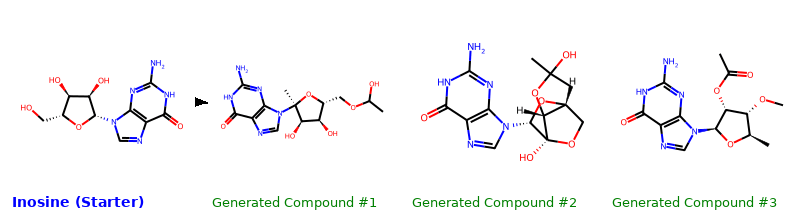

In [14]:
# Ensure needed imports exist (if not already present)
from PIL import Image, ImageDraw, ImageFont

# Step 3: Helper functions (no change in logic, only formatting)
import math

def smiles_to_image(smiles, img_size=(250, 250)):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        img = Image.new('RGB', img_size, 'white')
        ImageDraw.Draw(img).text((10, img_size[1] // 2), "Invalid SMILES", fill='red')
        return img
    return Draw.MolToImage(mol, size=img_size)


def draw_arrow(draw, x1, y1, x2, y2, color='black', width=8, head_len=12, head_angle_deg=20):
    draw.line([(x1, y1), (x2, y2)], fill=color, width=width)

    angle = math.atan2(y2 - y1, x2 - x1)
    head_angle = math.radians(head_angle_deg)
    lx = x2 - head_len * math.cos(angle - head_angle)
    ly = y2 - head_len * math.sin(angle - head_angle)
    rx = x2 - head_len * math.cos(angle + head_angle)
    ry = y2 - head_len * math.sin(angle + head_angle)

    draw.polygon([(x2, y2), (lx, ly), (rx, ry)], fill=color)

def create_frame(starter_smi, gen_smiles_chunk, chunk_start_idx, mol_size=(180, 180)):
    padding, gap = 12, 20
    mol_w, mol_h = mol_size
    label_height = 20  # reserve space below molecules for labels
    frame_width = padding*2 + 4*mol_w + 3*gap
    frame_height = padding*2 + mol_h + label_height  # extra room for labels

    frame = Image.new('RGB', (frame_width, frame_height), 'white')
    draw = ImageDraw.Draw(frame)

    try:
        font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
        title_font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
    except (IOError, OSError):
        font = ImageFont.load_default()
        title_font = ImageFont.load_default()

    col0_x = padding
    col1_x = col0_x + mol_w + gap
    col2_x = col1_x + mol_w + gap
    col3_x = col2_x + mol_w + gap

    y0 = padding
    label_y = y0 + mol_h + 2  # consistent label position for all columns

    # Starter image
    starter_img = smiles_to_image(starter_smi, mol_size)
    frame.paste(starter_img, (col0_x, y0))
    draw.text((col0_x, label_y), "Inosine (Starter)", fill='blue', font=title_font)

    starter_center_y = y0 + mol_h // 2  # fixed: use // 2 not // 3
    starter_right_x = col0_x + mol_w

    for idx in range(3):
        gen_smi = gen_smiles_chunk[idx] if idx < len(gen_smiles_chunk) else None
        if gen_smi:
            gen_img = smiles_to_image(gen_smi, mol_size)
        else:
            gen_img = Image.new('RGB', mol_size, 'white')
            dd = ImageDraw.Draw(gen_img)
            dd.text((10, mol_h // 2), "No data", fill='gray', font=font)

        gen_x = [col1_x, col2_x, col3_x][idx]
        frame.paste(gen_img, (gen_x, y0))

        if idx == 0 and gen_smi is not None:
            gen_center_y = y0 + mol_h // 2
            draw_arrow(
                draw,
                starter_right_x + 5,
                starter_center_y,
                gen_x - 5,
                gen_center_y,
                color='black',
                width=2,
                head_len=12,
                head_angle_deg=20
            )

        label = f"Generated Compound #{chunk_start_idx + idx + 1}"
        draw.text((gen_x, label_y), label, fill='green', font=font)  # fixed: use label_y

    return frame

# Step 4: Build frames (3 generated molecules per frame, in a single row)
mols_per_frame = 3
genChunks = [uniqueGeneratedSmiles[i:i + mols_per_frame] for i in range(0, len(uniqueGeneratedSmiles), mols_per_frame)]

# Pad each chunk to exactly 3 items to keep layout consistent
for i, chunk in enumerate(genChunks):
    if len(chunk) < mols_per_frame:
        genChunks[i] = chunk + [None] * (mols_per_frame - len(chunk))

print(f"\nTotal frames available: {len(genChunks)}")

maxFrames = 100
if len(genChunks) > maxFrames:
    sampleIndices = np.linspace(0, len(genChunks) - 1, maxFrames, dtype=int)
    framesSampled = [(genChunks[i], i * mols_per_frame) for i in sampleIndices]
else:
    framesSampled = [(chunk, i * mols_per_frame) for i, chunk in enumerate(genChunks)]
print(f"Frames to generate: {len(framesSampled)}")

allFrameImages = []
for frame_idx, (chunk, start_idx) in enumerate(framesSampled):
    allFrameImages.append(create_frame(STARTER_SMILES, chunk, start_idx))
    if (frame_idx + 1) % 50 == 0:
        print(f"Generated frame {frame_idx + 1}/{len(framesSampled)}")

# Step 5: Save as GIF (unchanged)
if allFrameImages:
    gifOutputPath = f"{fileNamePrefix}.gif"
    max_width = max(img.width for img in allFrameImages)
    max_height = max(img.height for img in allFrameImages)

    uniformFrames = []
    for img in allFrameImages:
        if img.size != (max_width, max_height):
            uniform = Image.new('RGB', (max_width, max_height), 'white')
            uniform.paste(img, (0, 0))
            uniformFrames.append(uniform)
        else:
            uniformFrames.append(img)

    uniformFrames[0].save(gifOutputPath, save_all=True, append_images=uniformFrames[1:],
                          duration=3000, loop=0)
    print(f"\nSaved GIF: {gifOutputPath}")
    print(f"Total frames: {len(uniformFrames)}, Frame size: {max_width} x {max_height}")

    from IPython.display import display, Image as IPImage
    display(IPImage(filename=gifOutputPath))
else:
    print("\nNo frames were generated!")

### Drug-Likeness Analysis of molecules present in `uniqueMolecules`

Drug-likeness is a qualitative assessment used in drug discovery to determine whether a molecule has physicochemical and structural properties consistent with orally active drugs. Molecules that satisfy drug-likeness criteria are more likely to exhibit favorable **absorption, distribution, metabolism, excretion, and toxicity (ADMET)** profiles.

In this analysis, each unique molecule is evaluated against **five widely used drug-likeness filters**:

### 1. Lipinski's Rule of Five (Ro5)
Proposed by **Christopher Lipinski (1997)**, this is the most well-known drug-likeness filter. It predicts poor absorption or permeation when **more than one** of the following conditions is violated:

- Molecular Weight ≤ 500 Da
- LogP ≤ 5
- Hydrogen Bond Donors (HBD) ≤ 5
- Hydrogen Bond Acceptors (HBA) ≤ 10

> **Reference:** Lipinski, C.A. et al. *Adv. Drug Deliv. Rev.* **23**, 3–25 (1997). [DOI:10.1016/S0169-409X(96)00423-1](https://doi.org/10.1016/S0169-409X(96)00423-1)

### 2. Veber's Rules
Proposed by **Veber et al. (2002)**, these rules focus on oral bioavailability based on molecular flexibility and polar surface area:

- Number of Rotatable Bonds ≤ 10
- Topological Polar Surface Area (TPSA) ≤ 140 Å²

> **Reference:** Veber, D.F. et al. *J. Med. Chem.* **45**, 2615–2623 (2002). [DOI:10.1021/jm020017n](https://doi.org/10.1021/jm020017n)

### 3. Ghose Filter
Proposed by **Ghose et al. (1999)**, this filter defines a drug-like chemical space using ranges for key properties:

- 160 ≤ Molecular Weight ≤ 480 Da
- −0.4 ≤ LogP ≤ 5.6
- 20 ≤ Number of Heavy Atoms ≤ 70
- 40 ≤ Molar Refractivity ≤ 130

> **Reference:** Ghose, A.K. et al. *J. Comb. Chem.* **1**, 55–68 (1999). [DOI:10.1021/cc9800071](https://doi.org/10.1021/cc9800071)

### 4. Egan Filter
Proposed by **Egan et al. (2000)**, this filter predicts passive intestinal absorption using a simple two-parameter model:

- LogP ≤ 5.88
- TPSA ≤ 131.6 Å²

> **Reference:** Egan, W.J. et al. *J. Med. Chem.* **43**, 3867–3877 (2000). [DOI:10.1021/jm000292e](https://doi.org/10.1021/jm000292e)

### 5. Muegge Filter
Proposed by **Muegge et al. (2001)**, this pharmacophore-based filter uses a broader set of criteria to identify drug-like molecules:

- 200 ≤ Molecular Weight ≤ 600 Da
- −2 ≤ LogP ≤ 5
- TPSA ≤ 150 Å²
- Number of Rings ≤ 7
- Hydrogen Bond Acceptors ≤ 10
- Hydrogen Bond Donors ≤ 5
- Number of Rotatable Bonds ≤ 15
- Number of Heavy Atoms ≥ 8

> **Reference:** Muegge, I. et al. *J. Med. Chem.* **44**, 1841–1846 (2001). [DOI:10.1021/jm015507e](https://doi.org/10.1021/jm015507e)

### Drug-Like Score

Each molecule receives a **DrugLikeScore** ranging from **0 to 5**, representing the number of filters it passes. A score of **5** indicates the molecule satisfies all five drug-likeness criteria, suggesting strong potential as an orally bioavailable drug candidate.

| DrugLikeScore | Interpretation |
|:---:|:---|
| 5 | Excellent drug-likeness — passes all filters |
| 4 | Strong drug-likeness — minor deviation in one filter |
| 3 | Moderate drug-likeness |
| 2 | Weak drug-likeness |
| 1 | Poor drug-likeness |
| 0 | Not drug-like by any standard filter |

### Molecular Properties Computed

| Property | Description | Used By |
|:---|:---|:---|
| Molecular Weight (MW) | Exact molecular weight in Daltons | Lipinski, Ghose, Muegge |
| LogP | Octanol-water partition coefficient (lipophilicity) | Lipinski, Ghose, Egan, Muegge |
| HBD | Number of hydrogen bond donors | Lipinski, Muegge |
| HBA | Number of hydrogen bond acceptors | Lipinski, Muegge |
| TPSA | Topological polar surface area (Å²) | Veber, Egan, Muegge |
| Rotatable Bonds | Number of rotatable bonds | Veber, Muegge |
| Heavy Atoms | Number of non-hydrogen atoms | Ghose, Muegge |
| Molar Refractivity | Measure of molecular polarizability | Ghose |
| Rings | Total number of rings | Muegge |
| Aromatic Rings | Number of aromatic rings | Structural characterization |

> **Note:** These filters are designed primarily for **orally active small molecules**. Natural products and biologics may legitimately violate some criteria while still being therapeutically relevant. The DrugLikeScore should be interpreted as a guide, not an absolute cutoff.

In [ ]:
from rdkit.Chem import Descriptors, rdMolDescriptors, Lipinski


# Drug-likeness filter functions
def computeDrugLikeProperties(smiles):
    """Compute drug-likeness properties from SMILES."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return pd.Series({
            'MolWeight': None,
            'LogP': None,
            'NumHBD': None,
            'NumHBA': None,
            'TPSA': None,
            'NumRotatableBonds': None,
            'NumRings': None,
            'NumAromaticRings': None,
            'NumHeavyAtoms': None,
            'MolarRefractivity': None,
            'PassesLipinski': False,
            'LipinskiViolations': None,
            'PassesVeber': False,
            'PassesGhose': False,
            'PassesEgan': False,
            'PassesMuegge': False,
            'DrugLikeScore': 0,
            'IsValidMol': False
        })

    molWeight = Descriptors.ExactMolWt(mol)
    logP = Descriptors.MolLogP(mol)
    numHBD = rdMolDescriptors.CalcNumHBD(mol)
    numHBA = rdMolDescriptors.CalcNumHBA(mol)
    tpsa = rdMolDescriptors.CalcTPSA(mol)
    numRotatableBonds = rdMolDescriptors.CalcNumRotatableBonds(mol)
    numRings = rdMolDescriptors.CalcNumRings(mol)
    numAromaticRings = rdMolDescriptors.CalcNumAromaticRings(mol)
    numHeavyAtoms = mol.GetNumHeavyAtoms()
    molarRefractivity = Descriptors.MolMR(mol)

    lipinskiViolations = 0
    if molWeight > 500:
        lipinskiViolations += 1
    if logP > 5:
        lipinskiViolations += 1
    if numHBD > 5:
        lipinskiViolations += 1
    if numHBA > 10:
        lipinskiViolations += 1
    passesLipinski = lipinskiViolations <= 1

    passesVeber = (numRotatableBonds <= 10) and (tpsa <= 140)

    passesGhose = (
        (160 <= molWeight <= 480) and
        (-0.4 <= logP <= 5.6) and
        (20 <= numHeavyAtoms <= 70) and
        (40 <= molarRefractivity <= 130)
    )

    passesEgan = (logP <= 5.88) and (tpsa <= 131.6)

    passesMuegge = (
        (200 <= molWeight <= 600) and
        (-2 <= logP <= 5) and
        (tpsa <= 150) and
        (numRings <= 7) and
        (numHBA <= 10) and
        (numHBD <= 5) and
        (numRotatableBonds <= 15) and
        (numHeavyAtoms >= 8)
    )

    drugLikeScore = sum([
        passesLipinski,
        passesVeber,
        passesGhose,
        passesEgan,
        passesMuegge
    ])

    return pd.Series({
        'MolWeight': round(molWeight, 4),
        'LogP': round(logP, 4),
        'NumHBD': numHBD,
        'NumHBA': numHBA,
        'TPSA': round(tpsa, 2),
        'NumRotatableBonds': numRotatableBonds,
        'NumRings': numRings,
        'NumAromaticRings': numAromaticRings,
        'NumHeavyAtoms': numHeavyAtoms,
        'MolarRefractivity': round(molarRefractivity, 4),
        'PassesLipinski': passesLipinski,
        'LipinskiViolations': lipinskiViolations,
        'PassesVeber': passesVeber,
        'PassesGhose': passesGhose,
        'PassesEgan': passesEgan,
        'PassesMuegge': passesMuegge,
        'DrugLikeScore': drugLikeScore,
        'IsValidMol': True
    })


# Compute drug-likeness for all molecules
print(f"Computing drug-likeness properties for {len(uniqueMolecules)} molecules...")

drugLikeProperties = uniqueMolecules['SMILES'].apply(computeDrugLikeProperties)

uniqueMoleculesDrug = pd.concat(
    [uniqueMolecules.reset_index(drop=True), drugLikeProperties],
    axis=1
)

invalidMolCount = len(uniqueMoleculesDrug[~uniqueMoleculesDrug['IsValidMol']])
print(f"Invalid molecules: {invalidMolCount}")
print(f"Final DataFrame shape: {uniqueMoleculesDrug.shape}")

# Summary
validMols = uniqueMoleculesDrug[uniqueMoleculesDrug['IsValidMol']]
totalValid = len(validMols)

lipinskiCount = validMols['PassesLipinski'].sum()
veberCount = validMols['PassesVeber'].sum()
ghoseCount = validMols['PassesGhose'].sum()
eganCount = validMols['PassesEgan'].sum()
mueggeCount = validMols['PassesMuegge'].sum()
allFiveCount = len(validMols[validMols['DrugLikeScore'] == 5])
nonePassedCount = len(validMols[validMols['DrugLikeScore'] == 0])

print("\nDrug likeliness summary:")
print(f"Total valid molecules: {totalValid}")
print(f"  Passes Lipinski (Ro5):  {lipinskiCount} ({lipinskiCount/totalValid*100:.2f}%)")
print(f"  Passes Veber:           {veberCount} ({veberCount/totalValid*100:.2f}%)")
print(f"  Passes Ghose:           {ghoseCount} ({ghoseCount/totalValid*100:.2f}%)")
print(f"  Passes Egan:            {eganCount} ({eganCount/totalValid*100:.2f}%)")
print(f"  Passes Muegge:          {mueggeCount} ({mueggeCount/totalValid*100:.2f}%)")
print(f"\n  Passes ALL 5 filters:   {allFiveCount} ({allFiveCount/totalValid*100:.2f}%)")
print(f"  Passes NONE:            {nonePassedCount} ({nonePassedCount/totalValid*100:.2f}%)")

# DrugLikeScore distribution
print(f"\nDrugLikeScore Distribution:")
for score in range(6):
    count = len(validMols[validMols['DrugLikeScore'] == score])
    print(f"  Score {score}/5: {count} ({count/totalValid*100:.2f}%)")

# Breakdown: starters vs generated
startersDrug = validMols[validMols['Is_Starter'] == True]
generatedDrug = validMols[validMols['Is_Starter'] == False]

starterAllFive = len(startersDrug[startersDrug['DrugLikeScore'] == 5])
generatedAllFive = len(generatedDrug[generatedDrug['DrugLikeScore'] == 5])

starterPercent = (starterAllFive / len(startersDrug) * 100) if len(startersDrug) > 0 else 0
generatedPercent = (generatedAllFive / len(generatedDrug) * 100) if len(generatedDrug) > 0 else 0

print(f"\nAmong starters:  {starterAllFive}/{len(startersDrug)} pass all 5 ({starterPercent:.2f}%)")
print(f"Among generated: {generatedAllFive}/{len(generatedDrug)} pass all 5 ({generatedPercent:.2f}%)")

uniqueMoleculesDrug

### Check matches for Natural Product from public data bases via `SMILES`
 - NPAtlas: https://www.npatlas.org/download
 - COCONUT: https://coconut.naturalproducts.net/download

## Natural Product Matching via `InChIKey`

# How many pathways has been generated

In [ ]:
import PyPDF2

# Find all *_pathways_visualized.pdf files in the current working directory
currentDir = os.getcwd()

allPathwayPdfFiles = sorted(glob.glob(os.path.join(currentDir, "*_pathways_visualized.pdf")))

totalStarterDirs = len(allPathwayPdfFiles)
print(f"Found {totalStarterDirs} pathway PDF files")

# Count pathways from each PDF file
pathwayCountsPerStarter = []

for pdfPath in allPathwayPdfFiles:
    fileName = os.path.basename(pdfPath)
    dirName = fileName.replace('_pathways_visualized.pdf', '')
    
    try:
        starterNum = int(dirName.replace('starter_', ''))
    except ValueError:
        starterNum = -1

    numPathways = 0
    try:
        with open(pdfPath, 'rb') as pdfFile:
            pdfReader = PyPDF2.PdfReader(pdfFile)
            numPathways = len(pdfReader.pages)
    except Exception as e:
        print(f"Error reading PDF {fileName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathwaysRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways = allPathwaysRaw[allPathwaysRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalPathways = allPathways['NumPathways'].sum()
startersWithPathways = len(allPathways)
startersWithoutPathways = totalStarterDirs - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs) * 100 if totalStarterDirs > 0 else 0
withoutPercent = (startersWithoutPathways / totalStarterDirs) * 100 if totalStarterDirs > 0 else 0

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways = allPathways.drop(columns=['StarterNum'])
allPathways

### Visualize pathways

In [ ]:
import os, sys, shutil

doranetBin = os.path.dirname(sys.executable)  # .../doranet_env/bin
os.environ["PATH"] = doranetBin + ":" + os.environ.get("PATH", "")

# optional: align CONDA_PREFIX to the python you're actually using
os.environ["CONDA_PREFIX"] = os.path.dirname(doranetBin)

print("python:", sys.executable)
print("CONDA_PREFIX:", os.environ.get("CONDA_PREFIX"))
print("dot:", shutil.which("dot"))

from graphviz import Digraph

In [ ]:
import os
import re
import hashlib
import glob
from dataclasses import dataclass
from typing import Dict, List, Tuple

from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import rdMolDraw2D
from rdkit.Chem import rdChemReactions

from graphviz import Digraph

# notebook display
try:
    from IPython.display import display, SVG, Image as IPyImage
except Exception:
    display = None
    SVG = None
    IPyImage = None


@dataclass
class Pathway:
    rank: int
    finalScore: float
    atomicEconomy: float
    reactions: List[str]
    ruleNames: List[str]


def readTextFile(txtPath: str) -> str:
    with open(txtPath, "r", encoding="utf-8") as f:
        return f.read()


def parseRankedPathwayTxt(txt: str) -> List[Pathway]:
    blocks = re.split(r"\branking\s+", txt.strip())
    pathways: List[Pathway] = []

    for block in blocks:
        if not block.strip():
            continue

        rankMatch = re.match(r"(\d+)\s*", block)
        if not rankMatch:
            continue
        rank = int(rankMatch.group(1))

        def findFloat(pattern: str, default: float = float("nan")) -> float:
            m = re.search(pattern, block)
            return float(m.group(1)) if m else default

        finalScore = findFloat(r"final score\s+([0-9.]+)")
        atomicEconomy = findFloat(r"atomic economy\s+([0-9.]+)")

        reactionLines = []
        for line in block.splitlines():
            line = line.strip()
            if ">>" in line and not line.lower().startswith("reaction smiles"):
                reactionLines.append(line)

        ruleNames = [ln.strip() for ln in block.splitlines() if ln.strip().startswith("rule")]

        pathways.append(Pathway(rank, finalScore, atomicEconomy, reactionLines, ruleNames))

    pathways.sort(key=lambda p: p.rank)
    return pathways


def safeId(s: str) -> str:
    return hashlib.md5(s.encode("utf-8")).hexdigest()[:12]


def reactionFromSmiles(rxnSmiles: str) -> rdChemReactions.ChemicalReaction:
    return rdChemReactions.ReactionFromSmarts(rxnSmiles, useSmiles=True)


def drawReactionPng(rxnSmiles: str, outPath: str, width: int = 1800, height: int = 450) -> None:
    rxn = reactionFromSmiles(rxnSmiles)
    drawer = rdMolDraw2D.MolDraw2DCairo(width, height)
    opts = drawer.drawOptions()
    opts.fixedBondLength = 25
    opts.padding = 0.05
    drawer.DrawReaction(rxn)
    drawer.FinishDrawing()
    with open(outPath, "wb") as f:
        f.write(drawer.GetDrawingText())


def molPngFromSmiles(smiles: str, outPath: str, size: Tuple[int, int] = (420, 320)) -> None:
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        raise ValueError(f"Could not parse SMILES: {smiles}")
    Chem.rdDepictor.Compute2DCoords(mol)
    img = Draw.MolToImage(mol, size=size)
    img.save(outPath)


def splitReactionSmiles(rxnSmiles: str) -> Tuple[List[str], List[str]]:
    left, right = rxnSmiles.split(">>")
    reactants = [s for s in left.split(".") if s]
    products = [s for s in right.split(".") if s]
    return reactants, products


def requireNonEmpty(path: str, label: str) -> None:
    if not os.path.exists(path):
        raise FileNotFoundError(f"{label} was not created: {path}")
    size = os.path.getsize(path)
    if size == 0:
        raise RuntimeError(f"{label} is empty (0 bytes): {path}")
    print(f"{label}: {path} ({size} bytes)")


def buildPathwayGraphSvgBytes(
    pathway: Pathway,
    outDir: str,
    figureBaseName: str,
    graphDpi: int = 300
) -> Tuple[bytes, Dict[str, str]]:
    os.makedirs(outDir, exist_ok=True)
    nodeImgDir = os.path.join(outDir, f"{figureBaseName}_node_imgs")
    os.makedirs(nodeImgDir, exist_ok=True)

    g = Digraph(format="svg", engine="dot")
    g.attr(rankdir="LR", dpi=str(graphDpi))
    g.attr("node", fontname="Helvetica", fontsize="10")

    molImgCache: Dict[str, str] = {}

    def addMolNode(smiles: str) -> str:
        if smiles not in molImgCache:
            imgPath = os.path.abspath(os.path.join(nodeImgDir, f"mol_{safeId(smiles)}.png"))
            molPngFromSmiles(smiles, imgPath, size=(420, 320))
            molImgCache[smiles] = imgPath

        nodeId = f"mol_{safeId(smiles)}"
        g.node(nodeId, label="", image=molImgCache[smiles], shape="none")
        return nodeId

    for stepIdx, rxnSmiles in enumerate(pathway.reactions, start=1):
        reactants, products = splitReactionSmiles(rxnSmiles)
        ruleLabel = pathway.ruleNames[stepIdx - 1] if stepIdx - 1 < len(pathway.ruleNames) else f"step{stepIdx}"

        stepNodeId = f"rxn_{pathway.rank}_{stepIdx}"
        g.node(stepNodeId, label=ruleLabel, shape="box")

        for rSmiles in reactants:
            rNode = addMolNode(rSmiles)
            g.edge(rNode, stepNodeId)

        for pSmiles in products:
            pNode = addMolNode(pSmiles)
            g.edge(stepNodeId, pNode)

    g.attr(
        label=f"Rank {pathway.rank} | score {pathway.finalScore:.2f} | atomic economy {pathway.atomicEconomy:.3f}",
        labelloc="t",
        fontsize="12"
    )

    svgBytes = g.pipe(format="svg")
    return svgBytes, molImgCache


def svgBytesToPng(svgBytes: bytes, pngPath: str, scale: float = 2.0) -> None:
    import cairosvg
    cairosvg.svg2png(bytestring=svgBytes, write_to=pngPath, scale=scale)


def visualizeRankedPathwaysFromTxtPath(
    rankedPathwayTxtPath: str,
    outDir: str,
    writePerStepPanels: bool = True,
    graphDpi: int = 300,
    svgToPngScale: float = 2.0,
    showInline: bool = True
) -> None:
    txt = readTextFile(rankedPathwayTxtPath)
    pathways = parseRankedPathwayTxt(txt)
    os.makedirs(outDir, exist_ok=True)

    print("Writing to:", outDir)

    for p in pathways:
        print("\n=== Rank", p.rank, "===")

        # A) per-step reaction panels
        if writePerStepPanels:
            stepDir = os.path.join(outDir, f"rank{p.rank:02d}_steps")
            os.makedirs(stepDir, exist_ok=True)
            for i, rxnSmiles in enumerate(p.reactions, start=1):
                outPath = os.path.join(stepDir, f"rank{p.rank:02d}_step{i:02d}.png")
                drawReactionPng(rxnSmiles, outPath, width=1800, height=450)
                requireNonEmpty(outPath, f"Step PNG (rank {p.rank}, step {i})")

                if showInline and display and IPyImage:
                    display(IPyImage(filename=outPath))

        # B) pathway SVG via Graphviz pipe
        baseName = f"pathway_rank{p.rank:02d}"
        svgPath = os.path.join(outDir, f"{baseName}.svg")
        pngPath = os.path.join(outDir, f"{baseName}.png")

        svgBytes, molImgCache = buildPathwayGraphSvgBytes(
            p, outDir=outDir, figureBaseName=baseName, graphDpi=graphDpi
        )

        with open(svgPath, "wb") as f:
            f.write(svgBytes)
        requireNonEmpty(svgPath, f"Pathway SVG (rank {p.rank})")

        if showInline and display and SVG:
            display(SVG(data=svgBytes))

        # C) optional SVG -> PNG (requires CairoSVG)
        try:
            svgBytesToPng(svgBytes, pngPath, scale=svgToPngScale)
            requireNonEmpty(pngPath, f"Pathway PNG (rank {p.rank})")
            if showInline and display and IPyImage:
                display(IPyImage(filename=pngPath))
        except Exception as e:
            print(f"Skipping PNG conversion for rank {p.rank} (CairoSVG issue): {e}")

    print("\nDone.")


# ************************************************************
# Find *_ranked_pathways.txt in current directory and process
# ************************************************************
currentDir = os.getcwd()
rankedPathwayTxtFiles = sorted(glob.glob(os.path.join(currentDir, "*_ranked_pathways.txt")))

print(f"Found {len(rankedPathwayTxtFiles)} ranked pathway text files in current directory")

for txtPath in rankedPathwayTxtFiles:
    fileName = os.path.basename(txtPath)
    baseName = fileName.replace("_ranked_pathways.txt", "")
    outDir = os.path.join(currentDir, f"{baseName}_publication_figures")

    print(f"\n{'='*60}")
    print(f"Processing: {fileName}")
    print(f"Output directory: {outDir}")
    print(f"{'='*60}")

    visualizeRankedPathwaysFromTxtPath(
        rankedPathwayTxtPath=txtPath,
        outDir=outDir,
        writePerStepPanels=True,
        graphDpi=300,
        svgToPngScale=3.0,
        showInline=True
    )

### Discover All Starter Directories

In [ ]:
doranetOutputDir_NP = "doranet_output_NP"

helpersToExclude = {
    'O', 'O=O', '[H][H]', 'O=C=O', 'C=O', '[C-]#[O+]', 'Br', '[Br][Br]',
    'CO', 'C=C', 'O=S(O)O', 'N', 'O=S(=O)(O)O', 'O=NO', 'N#N',
    'O=[N+]([O-])O', 'NO', 'C#N', 'S', 'O=S=O', 'N#CO', '[H+]', 'OO',
    'Cl', 'I', 'O=C(O)O', 'O=P(O)(O)O', 'O=P(O)(O)OP(=O)(O)O', 'C',
    'CC', 'CC=O', 'CC(=O)O', 'CCC(=O)O'
}

print(f"Output directory: {doranetOutputDir_NP}")
print(f"Number of helpers to exclude: {len(helpersToExclude)}")

In [ ]:
# Automatically find all starter directories
allStarterDirPaths_NP = sorted(glob.glob(os.path.join(doranetOutputDir_NP, "starter_*_NP")))

print(f"Found {len(allStarterDirPaths_NP)} starter directories")

# Find the molecules CSV file inside each directory
discoveredCsvFiles = []
directoriesWithMissingCsv = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)

    # Expected CSV file name matches directory name
    expectedCsvPath = os.path.join(starterDirPath, f"{dirName}_molecules.csv")

    if os.path.exists(expectedCsvPath):
        discoveredCsvFiles.append({
            'dirName': dirName,
            'dirPath': starterDirPath,
            'csvPath': expectedCsvPath,
            'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
        })
    else:
        # Try to find any molecules CSV in the directory as fallback
        fallbackCsvPaths = glob.glob(os.path.join(starterDirPath, "*_molecules.csv"))
        if fallbackCsvPaths:
            discoveredCsvFiles.append({
                'dirName': dirName,
                'dirPath': starterDirPath,
                'csvPath': fallbackCsvPaths[0],
                'starterNum': int(dirName.replace('starter_', '').replace('_NP', ''))
            })
        else:
            directoriesWithMissingCsv.append(dirName)

# Sort by starter number
discoveredCsvFiles.sort(key=lambda x: x['starterNum'])

print(f"Found {len(discoveredCsvFiles)} CSV files containing DORAnet generated molecules")
if directoriesWithMissingCsv:
    print(f"Missing CSV in {len(directoriesWithMissingCsv)} directories: "
          f"{directoriesWithMissingCsv[:10]}...")

### Read All CSV Files into a DataFrame

In [ ]:
# Read all CSV files and combine into one DataFrame
perStarterDataFrames = []
csvReadErrors = []

for fileInfo in discoveredCsvFiles:
    try:
        singleStarterMolecules = pd.read_csv(fileInfo['csvPath'])

        # Add source starter information
        singleStarterMolecules['SourceStarterNum'] = fileInfo['starterNum']
        singleStarterMolecules['SourceDirectory'] = fileInfo['dirName']

        perStarterDataFrames.append(singleStarterMolecules)

    except Exception as e:
        csvReadErrors.append({
            'dirName': fileInfo['dirName'],
            'csvPath': fileInfo['csvPath'],
            'error': str(e)
        })

# Concatenate all DataFrames
if perStarterDataFrames:
    allMoleculesWithDuplicates_wNP = pd.concat(perStarterDataFrames, ignore_index=True)
    print(f"Total rows read (with duplicates and helpers): {len(allMoleculesWithDuplicates_wNP)}")
    print(f"Columns: {list(allMoleculesWithDuplicates_wNP.columns)}")
    print(f"Unique SMILES (before cleaning): {allMoleculesWithDuplicates_wNP['SMILES'].nunique()}")
else:
    print("ERROR: No CSV files could be read!")

if csvReadErrors:
    print(f"\nFailed to read {len(csvReadErrors)} files:")
    for err in csvReadErrors[:5]:
        print(f"  {err['dirName']}: {err['error']}")

allMoleculesWithDuplicates_wNP

### Remove HELPERS and Deduplicate

In [ ]:
# Step 1: Remove helpers
allMoleculesWithoutHelpers = allMoleculesWithDuplicates_wNP[
    ~allMoleculesWithDuplicates_wNP['SMILES'].isin(helpersToExclude)
].copy()

helpersRemovedCount = len(allMoleculesWithDuplicates_wNP) - len(allMoleculesWithoutHelpers)
helpersKeptPercent = (len(allMoleculesWithoutHelpers) / len(allMoleculesWithDuplicates_wNP)) * 100
print(f"Step 1 - Removed {helpersRemovedCount} helper molecules")
print(f"Remaining molecules: {len(allMoleculesWithoutHelpers)} ({helpersKeptPercent:.2f}%)")

# Step 2: Aggregate source starters per unique SMILES
sourceStarterMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceStarterNum']
    .apply(lambda x: sorted(set(x)))
    .reset_index()
)
sourceStarterMapping.columns = ['SMILES', 'SourceStarterList']
sourceStarterMapping['NumSourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(len)
sourceStarterMapping['SourceStarters'] = sourceStarterMapping['SourceStarterList'].apply(
    lambda x: ';'.join(map(str, x))
)

# Also aggregate source directories per unique SMILES
sourceDirectoryMapping = (
    allMoleculesWithoutHelpers
    .groupby('SMILES')['SourceDirectory']
    .apply(lambda x: ';'.join(sorted(set(x))))
    .reset_index()
)
sourceDirectoryMapping.columns = ['SMILES', 'SourceDirectories']

# Step 3: Deduplicate - keep first occurrence of each SMILES
uniqueMolecules_wNP = allMoleculesWithoutHelpers.drop_duplicates(
    subset='SMILES', keep='first'
).copy()

# Keep only desired columns
uniqueMolecules_wNP = uniqueMolecules_wNP[['SMILES', 'Is_Starter']].copy()

# Step 4: Merge aggregated source starter and directory information
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceStarterMapping[['SMILES', 'NumSourceStarters', 'SourceStarters']],
    on='SMILES',
    how='left'
)
uniqueMolecules_wNP = uniqueMolecules_wNP.merge(
    sourceDirectoryMapping,
    on='SMILES',
    how='left'
)

duplicatesRemovedCount = len(allMoleculesWithoutHelpers) - len(uniqueMolecules_wNP)
dedupeKeptPercent = (len(uniqueMolecules_wNP) / len(allMoleculesWithoutHelpers)) * 100
overallKeptPercent = (len(uniqueMolecules_wNP) / len(allMoleculesWithDuplicates_wNP)) * 100

print(f"Step 2 - Removed {duplicatesRemovedCount} duplicate molecular SMILES ({dedupeKeptPercent:.2f}%)")
print(f"Final unique molecules: {len(uniqueMolecules_wNP)} ({overallKeptPercent:.2f}% of original)")

uniqueMolecules_wNP = uniqueMolecules_wNP.drop(columns=['NumSourceStarters', 'SourceStarters'])
uniqueMolecules_wNP

### How many pathways has been generated 

In [ ]:
import PyPDF2

# Count pathways from PDF files in each directory
pathwayCountsPerStarter = []

for starterDirPath in allStarterDirPaths_NP:
    dirName = os.path.basename(starterDirPath)
    starterNum = int(dirName.replace('starter_', '').replace('_NP', ''))

    expectedPdfPath = os.path.join(starterDirPath, f"{dirName}_pathways_visualized.pdf")

    if not os.path.exists(expectedPdfPath):
        fallbackPdfPaths = glob.glob(os.path.join(starterDirPath, "*_pathways_visualized.pdf"))
        expectedPdfPath = fallbackPdfPaths[0] if fallbackPdfPaths else None

    numPathways = 0
    if expectedPdfPath and os.path.exists(expectedPdfPath):
        try:
            with open(expectedPdfPath, 'rb') as pdfFile:
                pdfReader = PyPDF2.PdfReader(pdfFile)
                numPathways = len(pdfReader.pages)
        except Exception as e:
            print(f"Error reading PDF for {dirName}: {e}")

    pathwayCountsPerStarter.append({
        'StarterDirectory': dirName,
        'StarterNum': starterNum,
        'NumPathways': numPathways
    })

allPathways_wNPRaw = pd.DataFrame(pathwayCountsPerStarter).sort_values('StarterNum').reset_index(drop=True)

# Keep only starters with pathways
allPathways_wNP = allPathways_wNPRaw[allPathways_wNPRaw['NumPathways'] > 0].copy().reset_index(drop=True)

totalStarterDirs_NP = len(allStarterDirPaths_NP)
totalPathways = allPathways_wNP['NumPathways'].sum()
startersWithPathways = len(allPathways_wNP)
startersWithoutPathways = totalStarterDirs_NP - startersWithPathways
withPercent = (startersWithPathways / totalStarterDirs_NP) * 100
withoutPercent = (startersWithoutPathways / totalStarterDirs_NP) * 100

print(f"Total pathways found: {totalPathways}")
print(f"Starters with pathways: {startersWithPathways} ({withPercent:.2f}%), "
      f"without: {startersWithoutPathways} ({withoutPercent:.2f}%)")

allPathways_wNP = allPathways_wNP.drop(columns=['StarterNum'])
allPathways_wNP